# Notebook for experiments with skeletonization

Imports

In [2]:
from typing import List, Set
import numpy as np
import uuid
import networkx as nx
from rdp import rdp
import os
from cv2 import imread
from skimage.morphology import skeletonize
from ypstruct import structure
import gng
import matplotlib.pyplot as plt

Additional parameters:

In [3]:
epsilon = 6
binary_threshold = 160

RDP implementation:

In [4]:
def simplify_network(net, epsilon: float = 1.0) -> List[np.ndarray]:
    # Find endpoints and intersections
    degree = np.sum(net.C, axis=0)
    endpoints = set(np.where(degree == 1)[0])
    intersections = set(np.where(degree > 2)[0])
    
    simplified_segments = []
    visited_edges = set()
    
    def traverse_segment(start: int, current: int) -> tuple[List[np.ndarray], int]:
        segment = [net.w[start]]
        initial_start = start
        while current not in endpoints and current not in intersections:
            segment.append(net.w[current])
            neighbors = set(np.where(net.C[current] == 1)[0]) - {start}
            if not neighbors:
                break
            # Check for cycle - if we're back at the start
            next_node = neighbors.pop()
            if next_node == initial_start and len(segment) > 2:
                segment.append(net.w[current])  # Close the loop
                return segment, current
            start, current = current, next_node
        segment.append(net.w[current])
        return segment, current

    def process_node(node: int) -> None:
        neighbors = set(np.where(net.C[node] == 1)[0])
        for neighbor in neighbors:
            edge = tuple(sorted([node, neighbor]))
            if edge not in visited_edges:
                visited_edges.add(edge)
                segment, end = traverse_segment(node, neighbor)
                if len(segment) > 2:
                    simplified_segment = rdp(np.array(segment), epsilon)
                    # Only add if endpoints are preserved
                    if np.array_equal(simplified_segment[0], segment[0]) and np.array_equal(simplified_segment[-1], segment[-1]):
                        simplified_segments.append(simplified_segment)
                else:
                    # Always keep segments of length 2 to maintain connectivity
                    simplified_segments.append(np.array(segment))
                if end != neighbor:
                    process_node(end)

    # Start with endpoints and intersections if they exist
    start_nodes = endpoints.union(intersections)
    
    # If no endpoints or intersections (e.g., perfect circle),
    # start with any node
    if not start_nodes:
        start_nodes = {0}  # Start with first node
        
    for node in start_nodes:
        process_node(node)
    
    return simplified_segments

Simplified network to NetworkX graph:

In [5]:
def to_networkx(simplified_network: List[List[np.ndarray]]) -> nx.Graph:
    """
    Convert the simplified network to a NetworkX graph with labeled nodes and edge data.

    Args:
        simplified_network (List[List[np.ndarray]]): The simplified network as a list of segments,
            each segment is a list of points represented as numpy arrays.

    Returns:
        nx.Graph: A NetworkX graph with nodes labeled by coordinates and edges with endpoint data.
    """
    G = nx.Graph()
    for i, segment in enumerate(simplified_network):
        for j in range(len(segment) - 1):
            source_coord = tuple(segment[j])
            target_coord = tuple(segment[j + 1])
            print(f"Source: {source_coord}, Target: {target_coord}")
            
            # Create unique identifiers for source and target nodes
            source_id = hash(source_coord)
            target_id = hash(target_coord)

            # Add source node with attributes if not already present
            if source_id not in G:
                G.add_node(source_id, x=source_coord[0], y=source_coord[1], uuid=str(uuid.uuid4()))

            # Add target node with attributes if not already present
            if target_id not in G:
                G.add_node(target_id, x=target_coord[0], y=target_coord[1], uuid=str(uuid.uuid4()))

            # Calculate edge length
            length = np.linalg.norm(np.array(target_coord) - np.array(source_coord))

            # Add edge with segment ID and endpoint information
            G.add_edge(source_id, target_id, 
                        segment_id=i, 
                        uuid=str(uuid.uuid4()),
                        x1=source_coord[0],
                        y1=source_coord[1],
                        x2=target_coord[0],
                        y2=target_coord[1],
                        length=length)

    return G

Iterate over images in folder function

In [6]:
def iterate_over_images_in_folder(folder_path: str):
    for file in os.listdir(folder_path):
        if file.endswith((".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".gif")):
            yield file


In [7]:
def binary_image(image_path: str):
    image = imread(image_path, 0)
    binary = image > binary_threshold
    return binary

In [8]:
def skeleton_image(image_path: str):
    binary = binary_image(image_path)
    skeleton = skeletonize(binary)
    return skeleton

In [9]:
def get_image_points(skeleton: np.ndarray):
    points = []
    h, w = skeleton.shape
    for y in range(h):
        for x in range(w):
            # Threshold the pixel
            if skeleton[y, x] > 0:
                points.append([x, y])

    return np.array(points)

In [10]:
from pydantic import BaseModel
from dataclasses import dataclass
from typing import Generator, Any, Tuple, Optional
import networkx as nx

class Vector(BaseModel):
    id: str
    x1: float
    y1: float
    x2: float
    y2: float
    length: float

@dataclass
class Point:
    x: float
    y: float
    id: str

    def __hash__(self):
        return hash(self.uuid)

class GraphTraversal:
    def __init__(self, graph: nx.Graph):
        self.graph = graph

    def dfs_traversal(self, start_node: Any) -> Generator[Tuple[Point, Optional[Vector]], None, None]:
        visited_edges = set()

        def find_edge(x1: float, y1: float, x2: float, y2: float) -> Optional[dict]:
            for _, _, edge_data in self.graph.edges(data=True):
                if ((edge_data['x1'] == x1 and edge_data['y1'] == y1 and edge_data['x2'] == x2 and edge_data['y2'] == y2) or
                    (edge_data['x1'] == x2 and edge_data['y1'] == y2 and edge_data['x2'] == x1 and edge_data['y2'] == y1)):
                    return edge_data
            return None

        def _dfs(node_id: str, prev_x: Optional[float] = None, prev_y: Optional[float] = None):
            node_data = self.graph.nodes[node_id]
            point = Point(id=node_data["uuid"], x=node_data['x'], y=node_data['y'])
            
            incoming_vector = None
            if prev_x is not None and prev_y is not None:
                edge_data = find_edge(prev_x, prev_y, point.x, point.y)
                if edge_data:
                    incoming_vector = Vector(
                        id=edge_data['uuid'],
                        x1=prev_x,
                        y1=prev_y,
                        x2=point.x,
                        y2=point.y,
                        length=edge_data['length']
                    )
                else:
                    raise ValueError(f"Edge not found between {prev_x}, {prev_y} and {point.x}, {point.y}")
            
            yield point, incoming_vector

            for neighbor_id in self.graph.neighbors(node_id):
                edge = tuple(sorted([node_id, neighbor_id]))
                if edge not in visited_edges:
                    visited_edges.add(edge)
                    yield from _dfs(neighbor_id, point.x, point.y)

        yield from _dfs(start_node)

In [11]:
params = structure()
params.N = 20 # Number of neuronsq
params.maxit = 100 # Maximum number of iterations
params.L = 40 # Learning rate
params.epsilon_b = 0.2 # Basal lr
params.epsilon_n = 0.01 # Neighborhood lr
params.alpha = 0.5 # Learning rate decay
params.delta = 0.995 # Neighborhood radius decay
params.T = 60 # Number of epochs
    
def gng_process(image_points: np.ndarray):
    return gng.fit(image_points, params)

In [12]:
from typing import Tuple, Optional


def plot_graph_traversal(
    ax: plt.Axes, G: nx.Graph, traversal: List[Tuple[Point, Optional[Vector]]]
):
    """
    Plot the graph traversal with arrows on the given axes.

    Args:
        ax (plt.Axes): The matplotlib axes to plot on.
        G (nx.Graph): The NetworkX graph.
        traversal (List[Tuple[Point, Optional[Vector]]]): The traversal result.
    """
    # Plot all edges in light gray
    pos = {node: (G.nodes[node]["x"], G.nodes[node]["y"]) for node in G.nodes()}
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="lightgray", arrows=False)

    # Plot nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=30, node_color="lightblue")

    # Plot traversal with arrows
    for i, (point, vector) in enumerate(traversal):
        # Mark the first point in red for better visualization
        if i == 0:
            ax.scatter(point.x, point.y, color='red', s=100, zorder=10)
            
        if vector:
            print(
                f"Vector {i}: x1: {vector.x1}, y1: {vector.y1}, x2: {vector.x2}, y2: {vector.y2}"
            )
            dx = vector.x2 - vector.x1
            dy = vector.y2 - vector.y1
            abs_dx = abs(dx)
            abs_dy = abs(dy)
            
            vector_type = None
            if abs_dx == abs_dy:
                vector_type = "DiagonalVector"
            elif abs_dx > abs_dy:
                vector_type = "HorizontalVector"
            else:
                vector_type = "VerticalVector"
            ax.arrow(
                vector.x1,
                vector.y1,
                dx,
                dy,  # Swap x and y
                head_width=3,
                head_length=3,
                fc="r",
                ec="r",
                length_includes_head=True,
                alpha=0.5,
            )
            
            label_x, label_y = calculate_label_position(vector)
            ax.text(
                label_x,
                label_y,
                vector_type,
                ha="center",
                va="center",
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
            )

        # Add numbers to show traversal order
        ax.text(point.x, point.y, str(i), fontsize=8, ha="center", va="center")

    ax.set_title("Graph Traversal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axis("equal")
    ax.invert_yaxis()  # Invert y-axis to match image coordinates

def calculate_label_position(vector: Vector, offset: float = 1) -> Tuple[float, float]:
    """
    Calculate optimal position for vector type label.
    
    Args:
        vector: Vector object containing coordinates
        offset: Distance of label from vector in pixels
        
    Returns:
        Tuple of (x, y) coordinates for label position
    """
    # Calculate vector properties
    dx = vector.x2 - vector.x1
    dy = vector.y2 - vector.y1
    length = vector.length
    
    # Calculate unit normal vector (perpendicular to the vector)
    if length > 0:
        nx = -dy / length
        ny = dx / length
    else:
        nx, ny = 0, -1
        
    # Calculate midpoint
    mid_x = vector.x1 + dx/2
    mid_y = vector.y1 + dy/2
    
    # Position label along normal vector
    label_x = mid_x + nx * offset
    label_y = mid_y + ny * offset
    
    return label_x, label_y


def plot_network_result(
    image_path,
    network,
    network_params: structure,
    points: np.ndarray,
    image: np.ndarray,
    binary: np.ndarray,
    skeleton: np.ndarray,
    simplified_network: List[List[np.ndarray]],
):
    # Create a figure with four subplots side by side
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(40, 10))

    # Plot original image on the left
    ax1.imshow(image, cmap="gray")
    ax1.set_title(f"Original Image: {image_path}")
    ax1.axis("off")

    ax2.imshow(binary, cmap="gray")
    ax2.set_title("Binary Image")
    ax2.axis("off")

    # Plot skeletonized image in the middle-left
    ax3.imshow(skeleton, cmap="gray")
    ax3.set_title("Skeletonized Image")
    ax3.axis("off")

    # Plot GNG result in the middle-right
    ax4.grid()
    ax4.scatter(points[:, 0], points[:, 1], s=2)
    for i in range(network_params.N):
        for j in range(i + 1, network_params.N):
            if network.C[i, j] == 1:
                ax4.plot(
                    [network.w[i, 0], network.w[j, 0]],
                    [network.w[i, 1], network.w[j, 1]],
                    c="r",
                )

    ax4.scatter(network.w[:, 0], network.w[:, 1], s=60, c="y", edgecolors="r")

    ax4.set_title("GNG")
    ax4.set_xlabel("x")
    ax4.set_ylabel("y")
    ax4.axis("equal")
    ax4.invert_yaxis()  # Invert y-axis to match image coordinates

    # Plot simplified network on the right
    ax5.grid()
    ax5.scatter(points[:, 0], points[:, 1], s=2, alpha=0.3)
    for segment in simplified_network:
        ax5.plot(segment[:, 0], segment[:, 1], "r-", linewidth=2)

    ax5.set_title("Simplified Network")
    ax5.set_xlabel("x")
    ax5.set_ylabel("y")
    ax5.axis("equal")
    ax5.invert_yaxis()  # Invert y-axis to match image coordinates

    plt.tight_layout()
    plt.show()

In [13]:
def find_top_leftmost_point(graph: nx.Graph) -> Optional[Any]:
    """
    Finds the top-leftmost point in the graph based on x and y coordinates.
    If no nodes with degree 1 exist, returns the node with highest degree.

    Returns:
        Optional[Any]: The top-leftmost point node or None if the graph is empty.
    """
    if not graph.nodes:
        return None

    degree_one_nodes = [node for node in graph.nodes if graph.degree[node] == 1]
    
    if degree_one_nodes:
        return min(
            degree_one_nodes,
            key=lambda n: graph.nodes[n]["y"] + graph.nodes[n]["x"],
        )
    else:
        # Find node with maximum degree
        return max(graph.nodes, key=lambda n: graph.degree[n])

In [14]:
from enum import Enum
from dataclasses import dataclass
from typing import List, Optional, Tuple, Set
import uuid
import numpy as np
from scipy.interpolate import interp1d
import networkx as nx
import matplotlib.pyplot as plt
import logging

logging.basicConfig(level=logging.DEBUG)
logger = logging.getLogger(__name__)


class CurveType(Enum):
    CONVEX = "convex"
    CONCAVE = "concave"
    # If you want to explicitly handle straight segments:
    # STRAIGHT = "straight"


@dataclass
class Point_:
    x: float
    y: float
    id: str
    nx_id: str


@dataclass
class Vector_:
    id: str
    x1: float
    y1: float
    x2: float
    y2: float
    length: float


@dataclass
class InflectionPoint(Point_):
    curvature_before: float
    curvature_after: float


@dataclass
class Curve:
    id: str
    vectors: List[Vector_]
    type: CurveType
    start_point: Point_
    end_point: Point_


@dataclass
class CurveSegment:
    points: List[Point_]
    vectors: List[Vector_]
    curvature: np.ndarray
    curve_type: CurveType
    inflection_point: Optional[InflectionPoint] = None


class CurveAnalyzer:
    def __init__(self, graph: nx.Graph):
        self.graph = graph
        self.visited_vectors: Set[str] = set()
        logger.info("Initialized CurveAnalyzer")

    def analyze(self) -> List[Curve]:
        """Analyze graph by traversing from endpoints and intersections."""
        curves = []
        endpoints = self._find_endpoints()
        intersections = self._find_intersections()

        logger.debug(
            f"Found {len(endpoints)} endpoints and {len(intersections)} intersections."
        )

        # Trace curves starting from each endpoint
        for ep in endpoints:
            curve_segments = self._trace_curves_from_node(ep)
            for segment in curve_segments:
                segment_data = self._analyze_curve_segment(
                    segment["points"], segment["vectors"]
                )
                if segment_data:
                    curve_obj = self._create_curve(segment_data)
                    if curve_obj:
                        curves.append(curve_obj)
                        # Mark vectors as visited
                        for vector in curve_obj.vectors:
                            self.visited_vectors.add(vector.id)

        # Also trace from intersection nodes to capture closed structures or curves starting there
        for intersec in intersections:
            curve_segments = self._trace_curves_from_node(intersec)
            for segment in curve_segments:
                # Filter out visited vectors
                segment["vectors"] = [v for v in segment["vectors"] if v.id not in self.visited_vectors]
                if not segment["vectors"]:
                    continue
                    
                segment_data = self._analyze_curve_segment(
                    segment["points"], segment["vectors"]
                )
                if segment_data:
                    curve_obj = self._create_curve(segment_data)
                    if curve_obj:
                        curves.append(curve_obj)
                        # Mark vectors as visited
                        for vector in curve_obj.vectors:
                            self.visited_vectors.add(vector.id)

        logger.info(f"Analysis complete. Found {len(curves)} curves")
        return curves

    def _find_endpoints(self) -> List[str]:
        return [n for n in self.graph.nodes if self.graph.degree(n) == 1]

    def _find_intersections(self) -> List[str]:
        return [n for n in self.graph.nodes if self.graph.degree(n) > 2]

    def _trace_curves_from_node(self, start_node: str) -> List[dict]:
        """
        Trace curves from a given node (which can be endpoint or intersection).
        For intersection nodes (deg > 2), we have multiple neighbors. We'll attempt to trace a segment along each neighbor.
        For endpoints (deg == 1), typically just one neighbor.

        We follow until:
        - Another endpoint or intersection is encountered.
        - Direction changes.
        """
        segments = []
        neighbors = sorted(self.graph.neighbors(start_node))
        if len(neighbors) == 0:
            return segments  # isolated node or no edges

        for next_node in neighbors:
            # Skip if edge has been visited
            edge_data = self.graph[start_node][next_node]
            if "uuid" in edge_data and edge_data["uuid"] in self.visited_vectors:
                continue
                
            segment_points = [self._create_point(start_node)]
            segment_vectors = []
            current_node = next_node
            prev_node = start_node

            while True:
                segment_points.append(self._create_point(current_node))
                vec = self._create_vector((prev_node, current_node))
                if vec:
                    # Skip if vector has been visited
                    if vec.id in self.visited_vectors:
                        logger.debug(f"Skipping visited vector {vec.id}")
                        break
                    segment_vectors.append(vec)

                deg = self.graph.degree(current_node)
                if (deg == 1 and current_node != start_node) or deg > 2:
                    # Reached endpoint or intersection, stop
                    logger.debug(f"Reached endpoint or intersection at node {current_node}")
                    break

                # degree == 2, continue forward
                neighbors_2 = [
                    n for n in self.graph.neighbors(current_node) if n != prev_node
                ]
                if len(neighbors_2) == 0:
                    # Dead end
                    logger.debug(f"Dead end at node {current_node}")
                    break

                next_next_node = neighbors_2[0]

                prev_node = current_node
                current_node = next_next_node

            if len(segment_points) > 1 and len(segment_vectors) > 0:
                segments.append({"points": segment_points, "vectors": segment_vectors})

        return segments

    def _analyze_curve_segment(
        self, points: List[Point_], vectors: List[Vector_]
    ) -> Optional[CurveSegment]:
        logger.debug("Analyzing curve segment")
        coords = np.array([(p.x, p.y) for p in points])

        if len(coords) < 4:
            logger.debug("Not enough points for interpolation")
            return None

        t = np.linspace(0, 1, len(coords))
        kind = "cubic" if len(coords) >= 4 else "linear"
        spline = interp1d(
            x=t, y=coords.T, kind=kind, assume_sorted=True, fill_value="extrapolate"
        )

        t_sample = np.linspace(0, 1, 100)
        curve_points = spline(t_sample)

        dx = np.gradient(curve_points[0], t_sample)
        dy = np.gradient(curve_points[1], t_sample)
        d2x = np.gradient(dx, t_sample)
        d2y = np.gradient(dy, t_sample)

        denominator = (dx * dx + dy * dy) ** 1.5
        denominator[denominator == 0] = np.finfo(float).eps
        curvature = (dx * d2y - dy * d2x) / denominator

        # inflection_indices = np.where(np.diff(np.signbit(curvature)))[0]
        # inflection_point = None

        # if len(inflection_indices) > 0:
        #     idx = inflection_indices[0]
        #     if idx > 0 and idx < len(curvature) - 1:
        #         point_idx = int((idx / (len(curvature) - 1)) * (len(points) - 1))
        #         inflection_point = self._create_inflection_point(
        #             points[point_idx], curvature[idx - 1], curvature[idx + 1]
        #         )
        #         points = points[: point_idx + 1]
        #         vectors = vectors[:point_idx]
        #         curvature = curvature[:idx]

        curve_type = self._determine_curve_type(curvature)
        if not curve_type:
            logger.debug("Could not determine curve type, treating as straight line")
            # If desired, fallback to a straight classification:
            # curve_type = CurveType.STRAIGHT
            # Or pick one arbitrarily:
            curve_type = CurveType.CONVEX

        logger.debug(f"Curve segment analyzed. Type: {curve_type}")
        return CurveSegment(
            points=points,
            vectors=vectors,
            curvature=curvature,
            curve_type=curve_type,
            inflection_point=None,
        )

    def _determine_curve_type(self, curvature: np.ndarray) -> Optional[CurveType]:
        if len(curvature) == 0:
            return None
        threshold = len(curvature) * 0.7
        pos_curv = np.sum(curvature > 0.01)
        neg_curv = np.sum(curvature < -0.01)

        logger.debug(f"Curvature: {curvature}")
        logger.debug(
            f"Pos curvature: {pos_curv}. Neg curvature: {neg_curv}. Threshold: {threshold}"
        )
        if pos_curv > threshold:
            logger.debug("Determined curve type: CONVEX")
            return CurveType.CONVEX
        elif neg_curv > threshold:
            logger.debug("Determined curve type: CONCAVE")
            return CurveType.CONCAVE
        else:
            logger.debug("Low curvature, no clear type")
            return None

    def _create_curve(self, segment: CurveSegment) -> Optional[Curve]:
        if not segment.vectors:
            logger.debug("No vectors in segment to create a curve")
            return None
        curve = Curve(
            id=str(uuid.uuid4()),
            vectors=segment.vectors,
            type=segment.curve_type,
            start_point=segment.points[0],
            end_point=segment.inflection_point or segment.points[-1],
        )
        logger.debug(f"Created curve {curve.id} of type {curve.type}")
        return curve

    def _create_point(self, node_id: str) -> Optional[Point_]:
        node_data = self.graph.nodes[node_id]
        if "x" not in node_data or "y" not in node_data or "uuid" not in node_data:
            logger.debug(f"Missing required attributes for node {node_id}")
            return None
        point = Point_(
            x=round(node_data["x"]),
            y=round(node_data["y"]),
            id=node_data["uuid"],
            nx_id=node_id,
        )
        logger.debug(f"Created point {point.id} at ({point.x}, {point.y})")
        return point

    def _create_vector(self, edge: Tuple[str, str]) -> Optional[Vector_]:
        if edge[1] not in self.graph[edge[0]]:
            logger.debug(f"No edge data for edge {edge}")
            return None
        edge_data = self.graph[edge[0]][edge[1]]
        if "uuid" not in edge_data:
            logger.debug(f"Missing 'uuid' for edge {edge}")
            return None
        vector = Vector_(
            id=edge_data["uuid"],
            x1=round(self.graph.nodes[edge[0]]["x"]),
            y1=round(self.graph.nodes[edge[0]]["y"]),
            x2=round(self.graph.nodes[edge[1]]["x"]),
            y2=round(self.graph.nodes[edge[1]]["y"]),
            length=edge_data.get("length", 0.0),
        )
        logger.debug(f"Created vector {vector.id}")
        return vector

    def _create_inflection_point(
        self, point: Point_, curvature_before: float, curvature_after: float
    ) -> InflectionPoint:
        inflection_point = InflectionPoint(
            x=point.x,
            y=point.y,
            id=point.id,
            nx_id=point.nx_id,
            curvature_before=curvature_before,
            curvature_after=curvature_after,
        )
        logger.debug(f"Created inflection point {inflection_point.id}")
        return inflection_point

    def visualize(self, curves: List[Curve]) -> None:
        logger.info("Visualizing curves")
        plt.figure(figsize=(12, 8))

        pos = {
            node: (self.graph.nodes[node]["x"], self.graph.nodes[node]["y"])
            for node in self.graph.nodes()
        }
        nx.draw_networkx_edges(self.graph, pos, edge_color="lightgray", alpha=0.3)

        colors = {CurveType.CONVEX: "red", CurveType.CONCAVE: "blue"}

        plotted_types = set()

        for curve in curves:
            if not curve.vectors:
                continue
            points = [(vector.x1, vector.y1) for vector in curve.vectors]
            points.append((curve.vectors[-1].x2, curve.vectors[-1].y2))

            x, y = zip(*points)
            label = None
            if curve.type not in plotted_types:
                label = f"{curve.type.value.capitalize()} Curve"
                plotted_types.add(curve.type)

            plt.plot(
                x, y, color=colors.get(curve.type, "green"), linewidth=2, label=label
            )

            # Plot start and end points
            plt.scatter(
                [curve.start_point.x],
                [curve.start_point.y],
                color="green",
                s=100,
                marker="o",
            )
            plt.scatter(
                [curve.end_point.x], [curve.end_point.y], color="red", s=100, marker="x"
            )

        plt.title("Detected Curves Analysis")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.grid(True)
        if plotted_types:
            plt.legend()
        plt.axis("equal")
        plt.gca().invert_yaxis()
        logger.info("Visualization complete")
        plt.show()

    def debug_visualize_graph(self):
        plt.figure(figsize=(12, 8))
        pos = {
            node: (self.graph.nodes[node]["x"], self.graph.nodes[node]["y"])
            for node in self.graph.nodes()
        }

        nx.draw_networkx_edges(self.graph, pos, edge_color="gray")

        node_colors = []
        for n in self.graph.nodes():
            deg = self.graph.degree(n)
            if deg == 1:
                node_colors.append("red")
            elif deg == 2:
                node_colors.append("blue")
            else:
                node_colors.append("green")

        nx.draw_networkx_nodes(self.graph, pos, node_color=node_colors, node_size=100)

        labels = {node: f"{self.graph.degree(node)}" for node in self.graph.nodes()}
        nx.draw_networkx_labels(self.graph, pos, labels)

        plt.title(
            "Graph Structure (Red: endpoints, Blue: path nodes, Green: intersections)"
        )
        plt.axis("equal")
        plt.gca().invert_yaxis()
        plt.show()

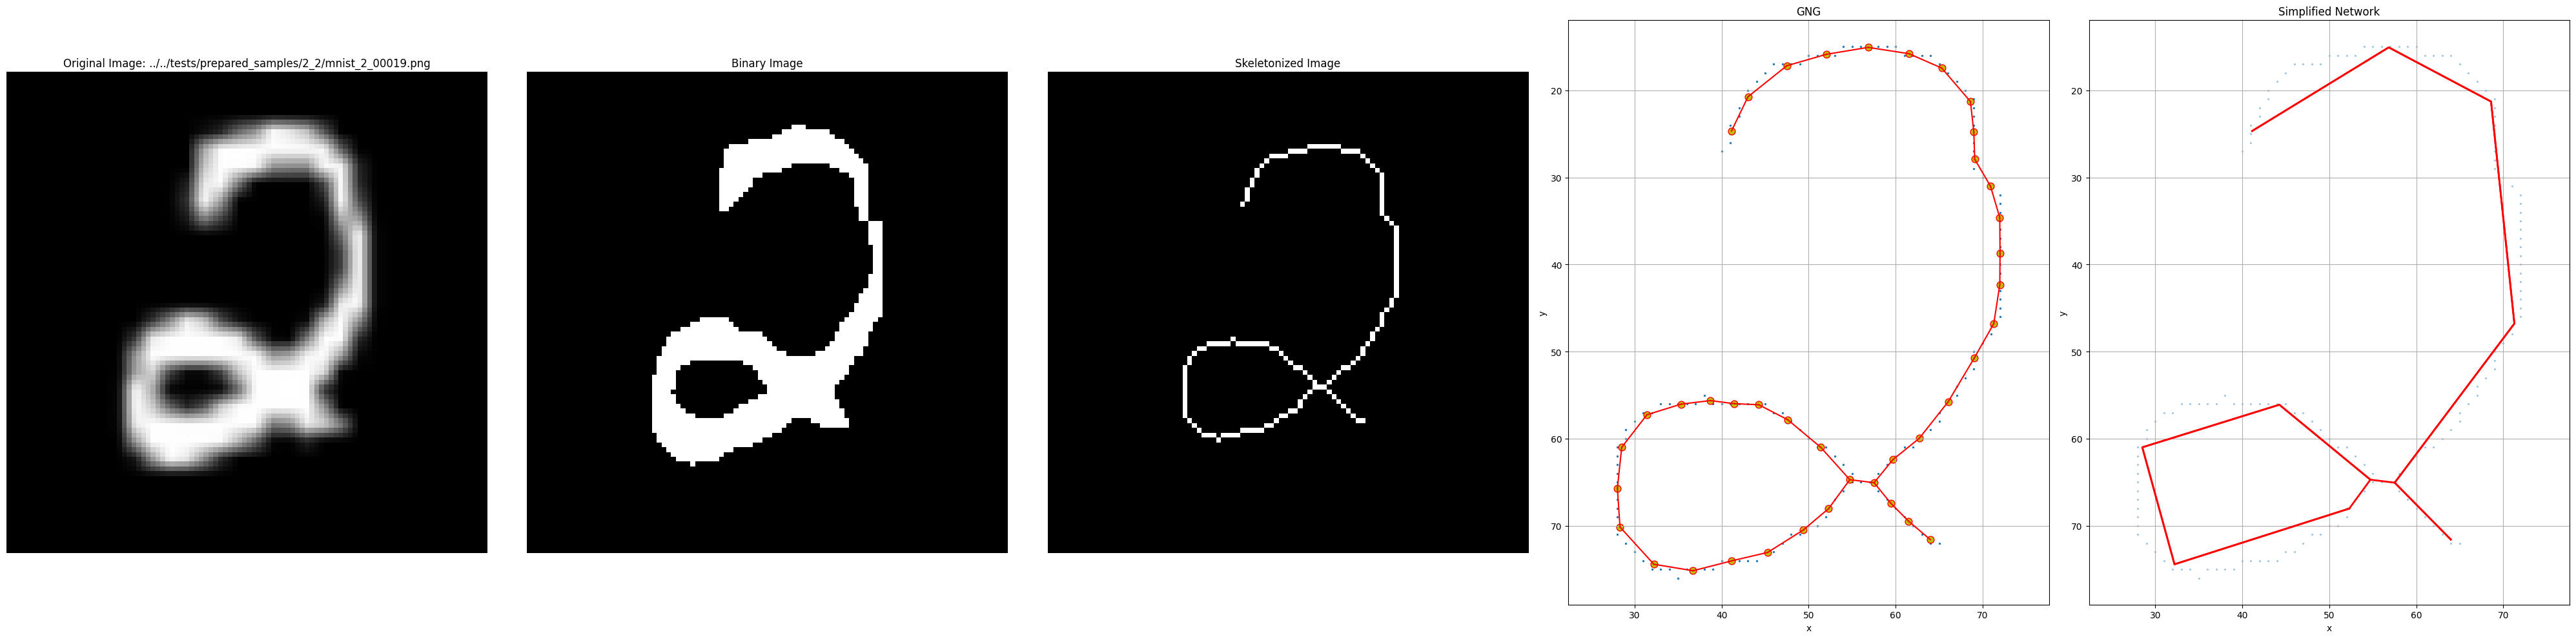

Source: (57.523998600612636, 65.05138703610392), Target: (71.28007281991361, 46.78161252702449)
Source: (71.28007281991361, 46.78161252702449), Target: (68.5961722740573, 21.28524249270076)
Source: (68.5961722740573, 21.28524249270076), Target: (56.8411616961054, 15.065837388259448)
Source: (56.8411616961054, 15.065837388259448), Target: (41.13880121587639, 24.668109526656895)
Source: (41.13880121587639, 24.668109526656895), Target: (56.8411616961054, 15.065837388259448)
Source: (56.8411616961054, 15.065837388259448), Target: (68.5961722740573, 21.28524249270076)
Source: (68.5961722740573, 21.28524249270076), Target: (71.28007281991361, 46.78161252702449)
Source: (71.28007281991361, 46.78161252702449), Target: (57.523998600612636, 65.05138703610392)
Source: (57.523998600612636, 65.05138703610392), Target: (54.73372222886367, 64.70908141901165)
Source: (57.523998600612636, 65.05138703610392), Target: (63.97873095501141, 71.58526566634977)
Source: (63.97873095501141, 71.58526566634977), 

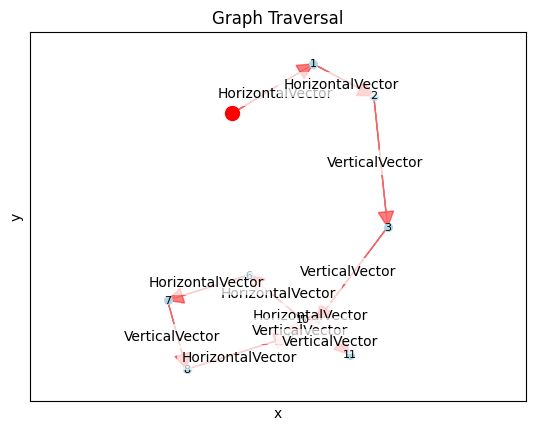

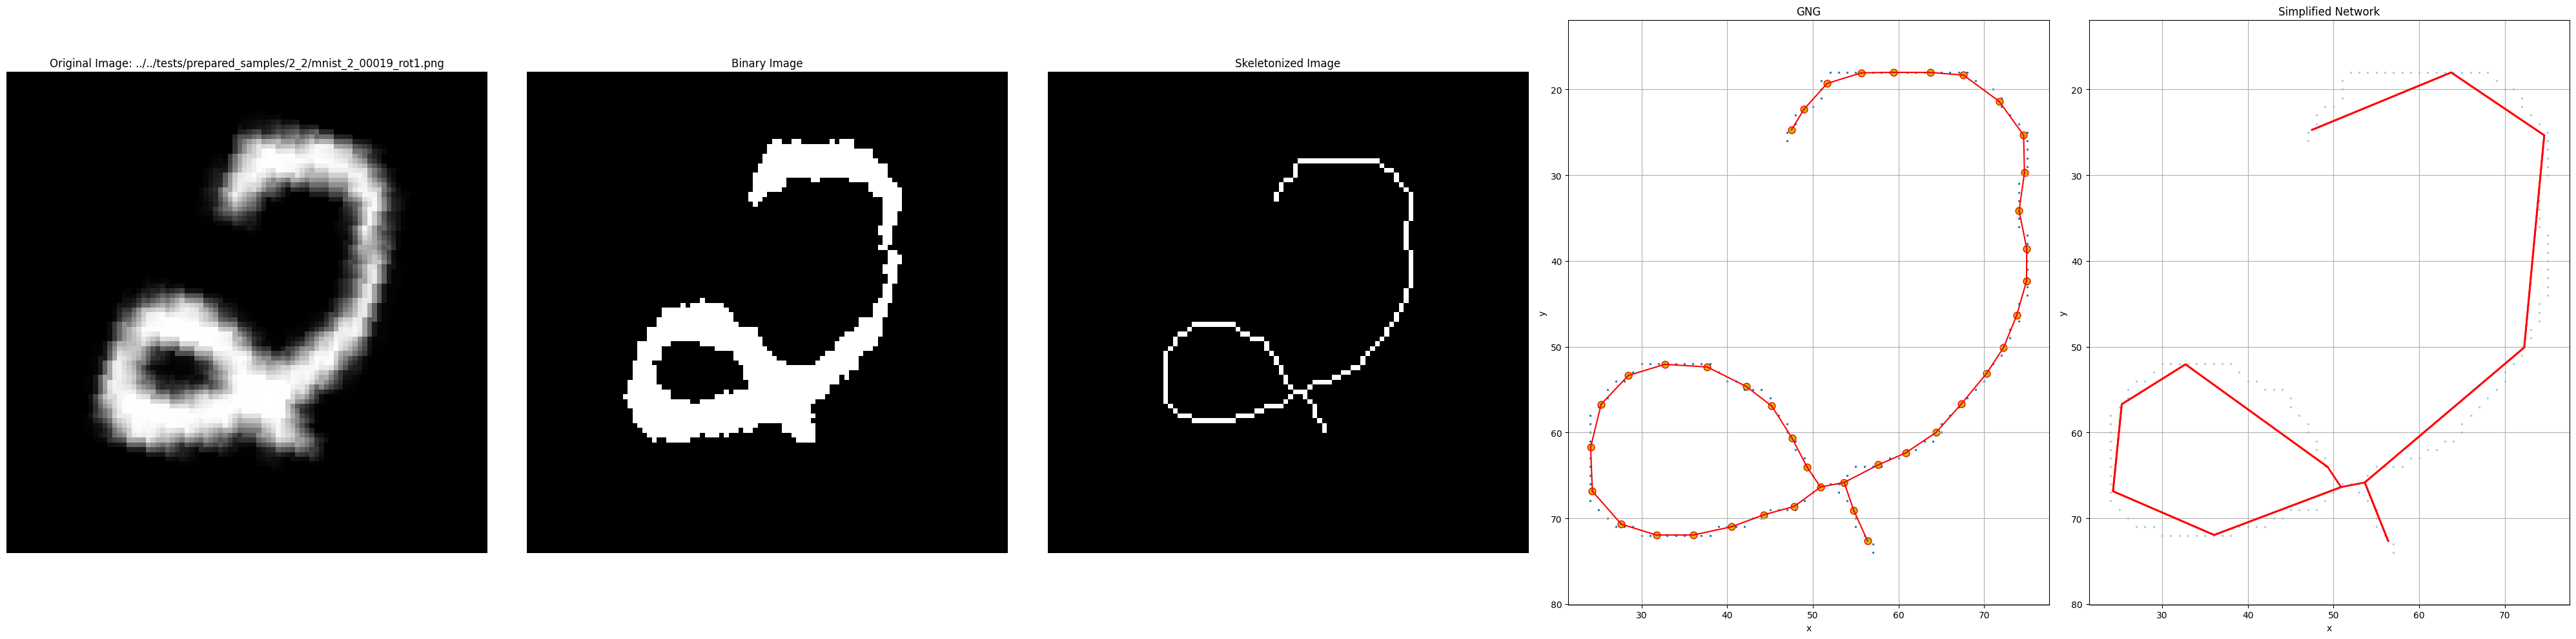

Source: (50.881981518851276, 66.37374746465933), Target: (53.65004020873283, 65.83177076018762)
Source: (50.881981518851276, 66.37374746465933), Target: (36.06724523667092, 71.95615626959373)
Source: (36.06724523667092, 71.95615626959373), Target: (24.260801007181108, 66.85582518216299)
Source: (24.260801007181108, 66.85582518216299), Target: (25.284929206472956, 56.708402597725765)
Source: (25.284929206472956, 56.708402597725765), Target: (32.72520763333136, 52.05333723400254)
Source: (32.72520763333136, 52.05333723400254), Target: (49.31134602039295, 64.0166662204966)
Source: (49.31134602039295, 64.0166662204966), Target: (50.881981518851276, 66.37374746465933)
Source: (49.31134602039295, 64.0166662204966), Target: (32.72520763333136, 52.05333723400254)
Source: (32.72520763333136, 52.05333723400254), Target: (25.284929206472956, 56.708402597725765)
Source: (25.284929206472956, 56.708402597725765), Target: (24.260801007181108, 66.85582518216299)
Source: (24.260801007181108, 66.8558251

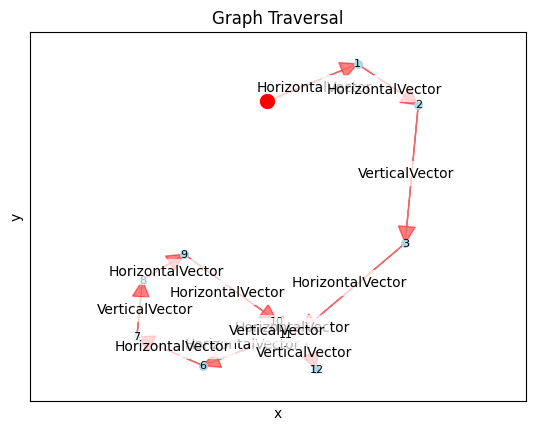

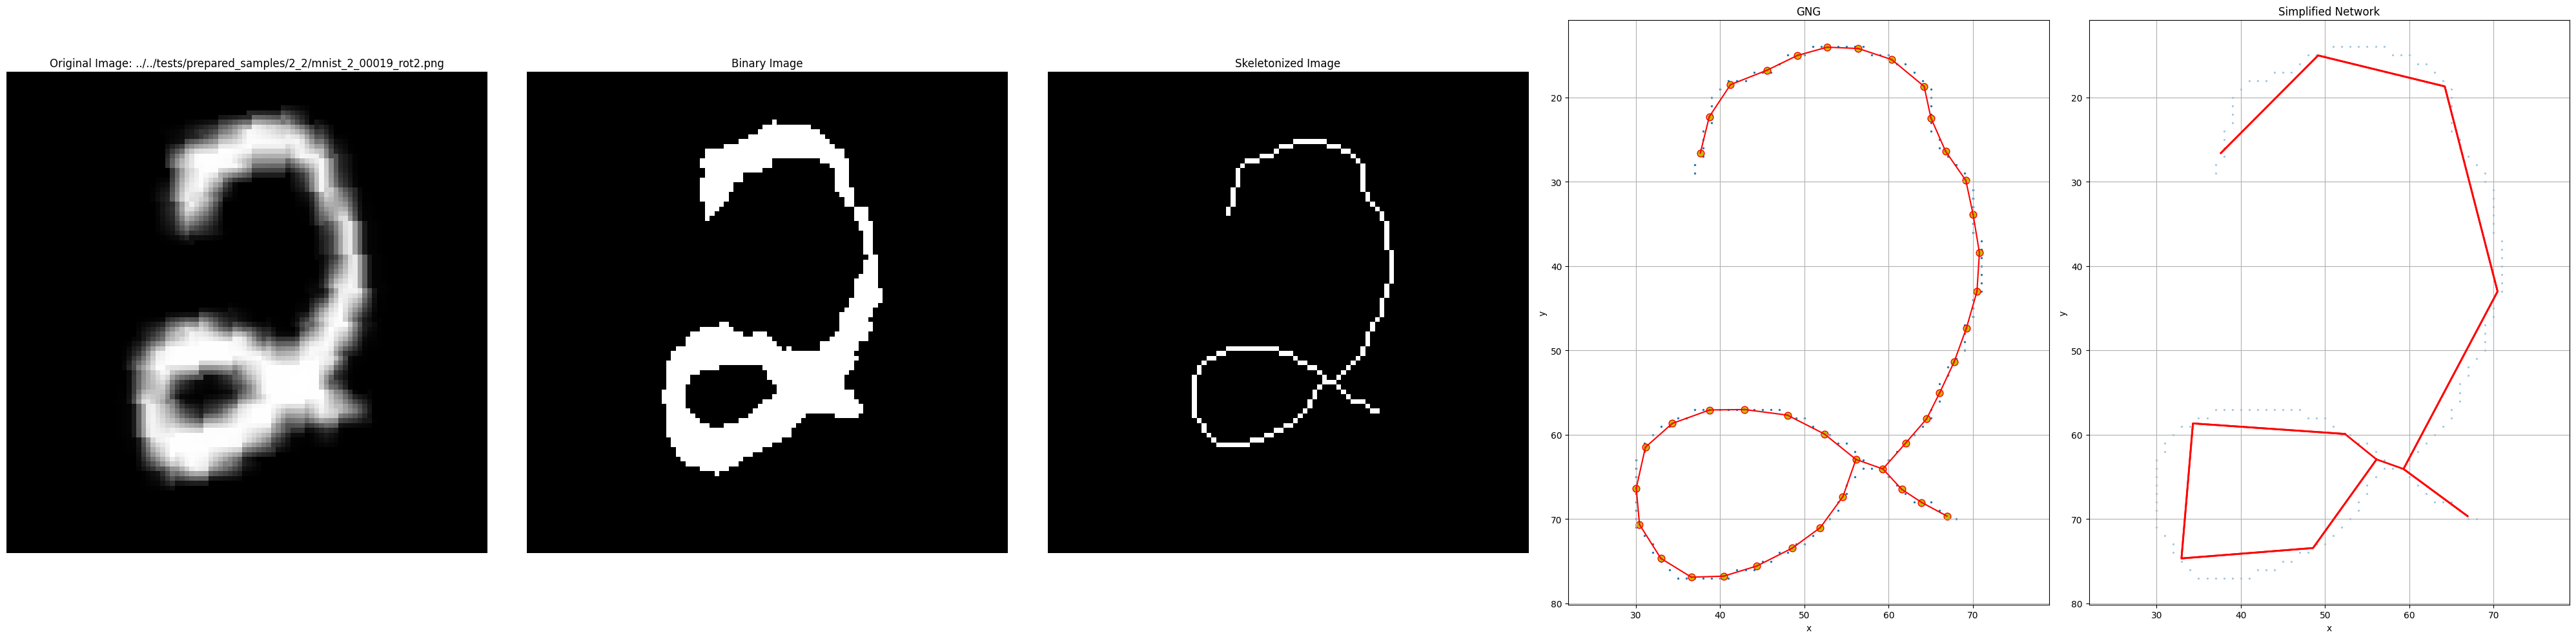

Source: (56.11867690485555, 62.933229737452535), Target: (59.31683310802048, 64.0667319402366)
Source: (56.11867690485555, 62.933229737452535), Target: (48.5782969190867, 73.44368242878478)
Source: (48.5782969190867, 73.44368242878478), Target: (32.96398835775664, 74.67330991126275)
Source: (32.96398835775664, 74.67330991126275), Target: (34.3251137015341, 58.66391093048689)
Source: (34.3251137015341, 58.66391093048689), Target: (52.358922197202375, 59.91122297385009)
Source: (52.358922197202375, 59.91122297385009), Target: (56.11867690485555, 62.933229737452535)
Source: (52.358922197202375, 59.91122297385009), Target: (34.3251137015341, 58.66391093048689)
Source: (34.3251137015341, 58.66391093048689), Target: (32.96398835775664, 74.67330991126275)
Source: (32.96398835775664, 74.67330991126275), Target: (48.5782969190867, 73.44368242878478)
Source: (48.5782969190867, 73.44368242878478), Target: (56.11867690485555, 62.933229737452535)
Source: (59.31683310802048, 64.0667319402366), Targe

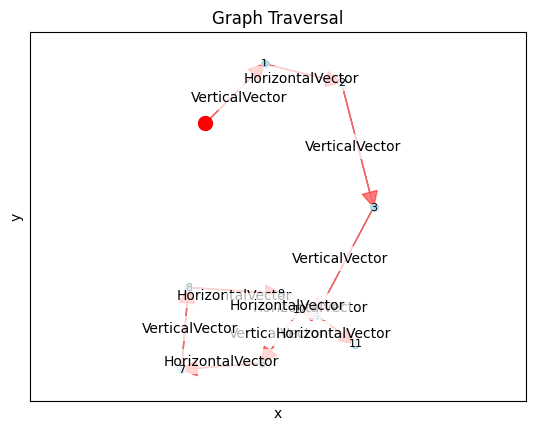

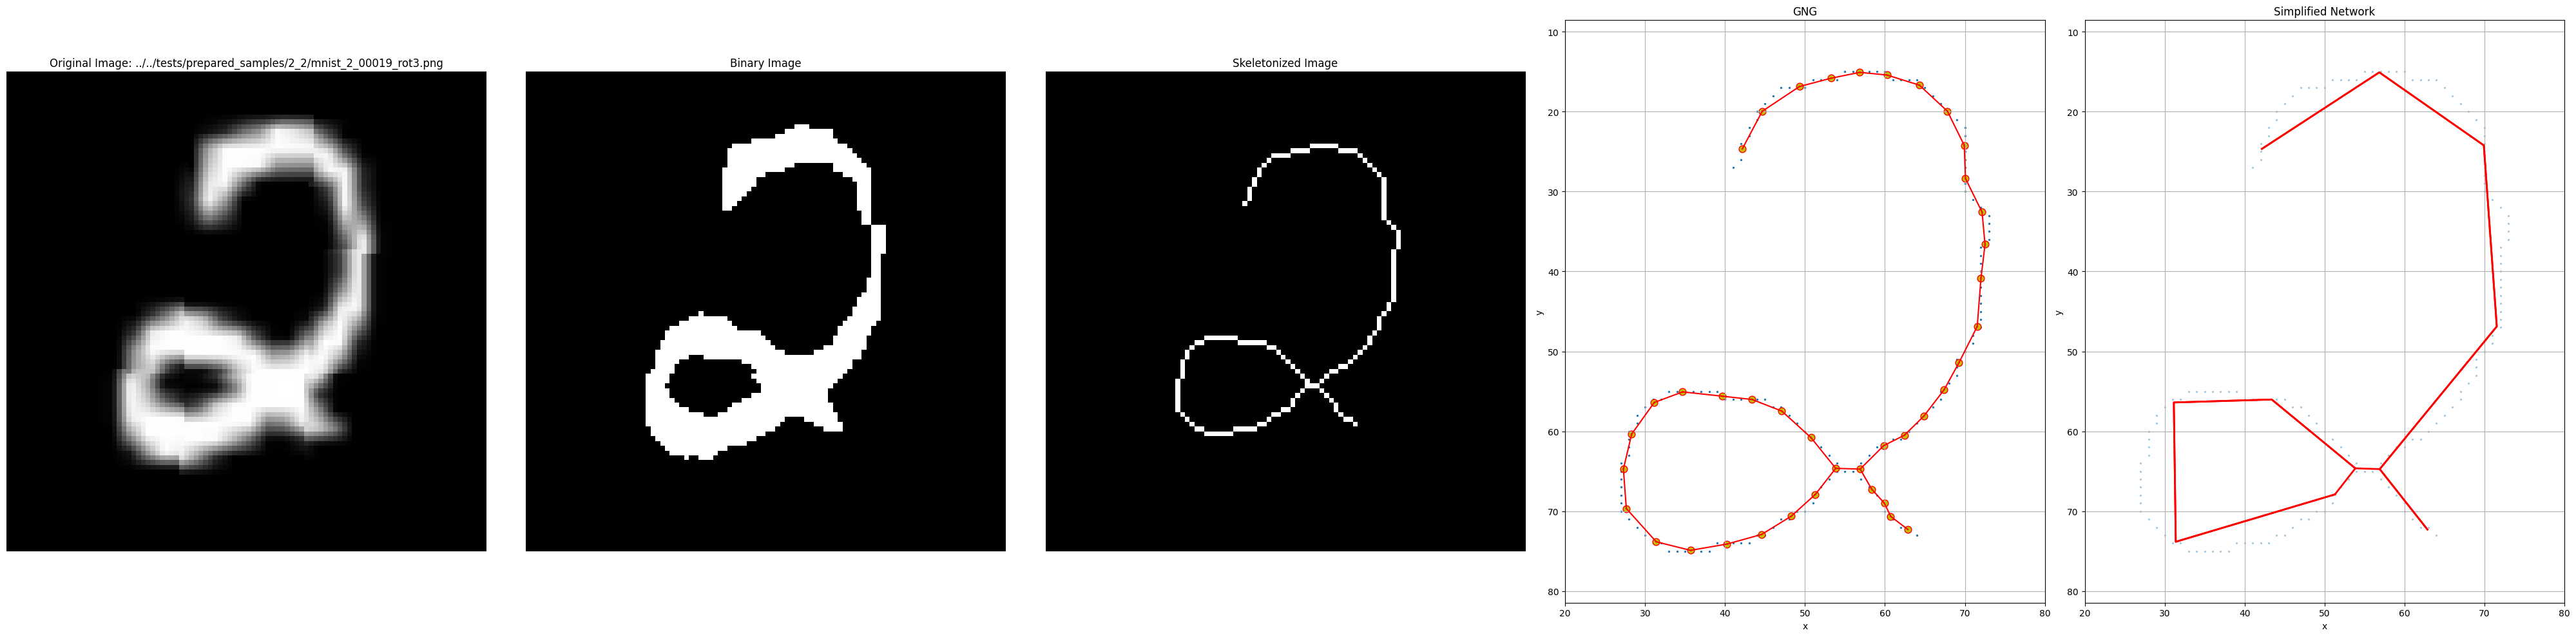

Source: (53.84689788458833, 64.6343228314349), Target: (56.90302089393559, 64.72990076836828)
Source: (53.84689788458833, 64.6343228314349), Target: (43.3943089544216, 56.02137188566083)
Source: (43.3943089544216, 56.02137188566083), Target: (31.143446589523894, 56.39264988118704)
Source: (31.143446589523894, 56.39264988118704), Target: (31.38872854930466, 73.82469316664336)
Source: (31.38872854930466, 73.82469316664336), Target: (51.29463873975882, 67.89945884824178)
Source: (51.29463873975882, 67.89945884824178), Target: (53.84689788458833, 64.6343228314349)
Source: (51.29463873975882, 67.89945884824178), Target: (31.38872854930466, 73.82469316664336)
Source: (31.38872854930466, 73.82469316664336), Target: (31.143446589523894, 56.39264988118704)
Source: (31.143446589523894, 56.39264988118704), Target: (43.3943089544216, 56.02137188566083)
Source: (43.3943089544216, 56.02137188566083), Target: (53.84689788458833, 64.6343228314349)
Source: (56.90302089393559, 64.72990076836828), Target

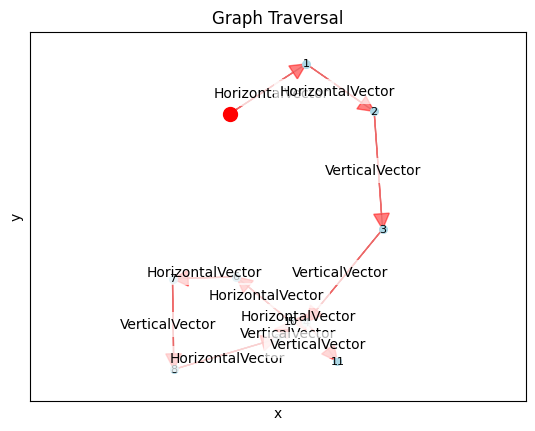

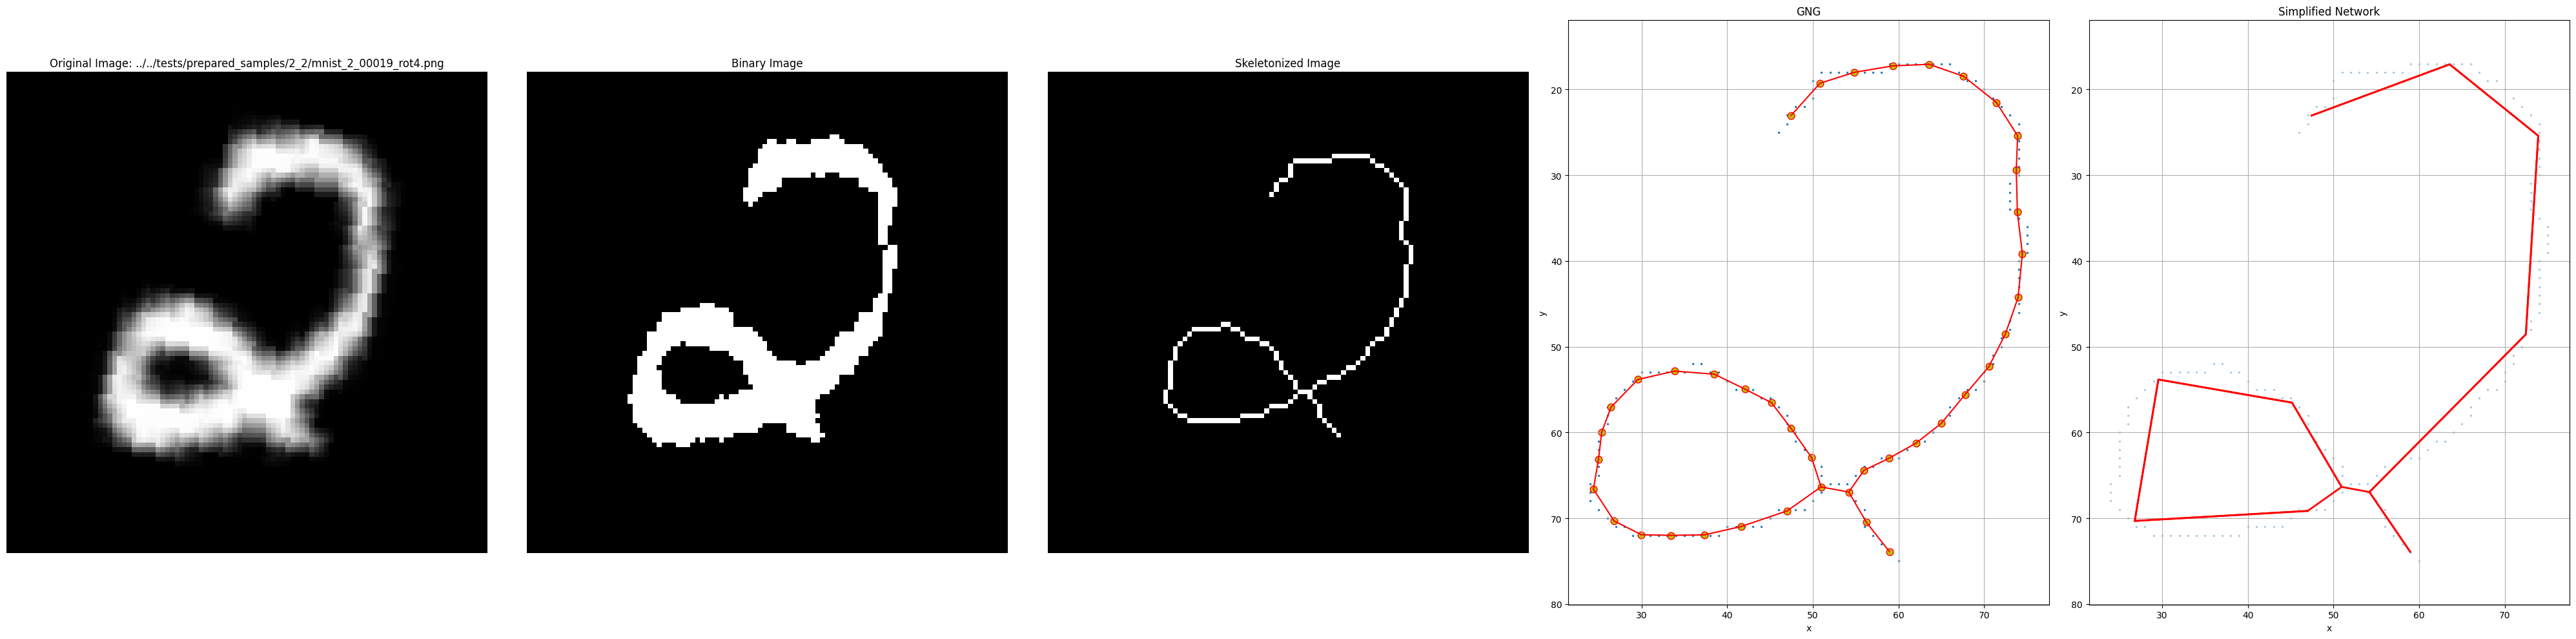

Source: (50.95164207835074, 66.35332004002885), Target: (54.1916253499102, 66.94823905165207)
Source: (50.95164207835074, 66.35332004002885), Target: (45.15937518967417, 56.52336576967523)
Source: (45.15937518967417, 56.52336576967523), Target: (29.560230782652503, 53.82753162462734)
Source: (29.560230782652503, 53.82753162462734), Target: (26.797899937592295, 70.31911306779824)
Source: (26.797899937592295, 70.31911306779824), Target: (46.98956541876361, 69.15054050945653)
Source: (46.98956541876361, 69.15054050945653), Target: (50.95164207835074, 66.35332004002885)
Source: (46.98956541876361, 69.15054050945653), Target: (26.797899937592295, 70.31911306779824)
Source: (26.797899937592295, 70.31911306779824), Target: (29.560230782652503, 53.82753162462734)
Source: (29.560230782652503, 53.82753162462734), Target: (45.15937518967417, 56.52336576967523)
Source: (45.15937518967417, 56.52336576967523), Target: (50.95164207835074, 66.35332004002885)
Source: (54.1916253499102, 66.9482390516520

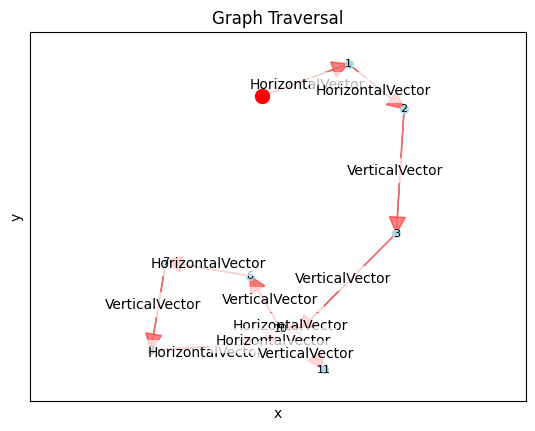

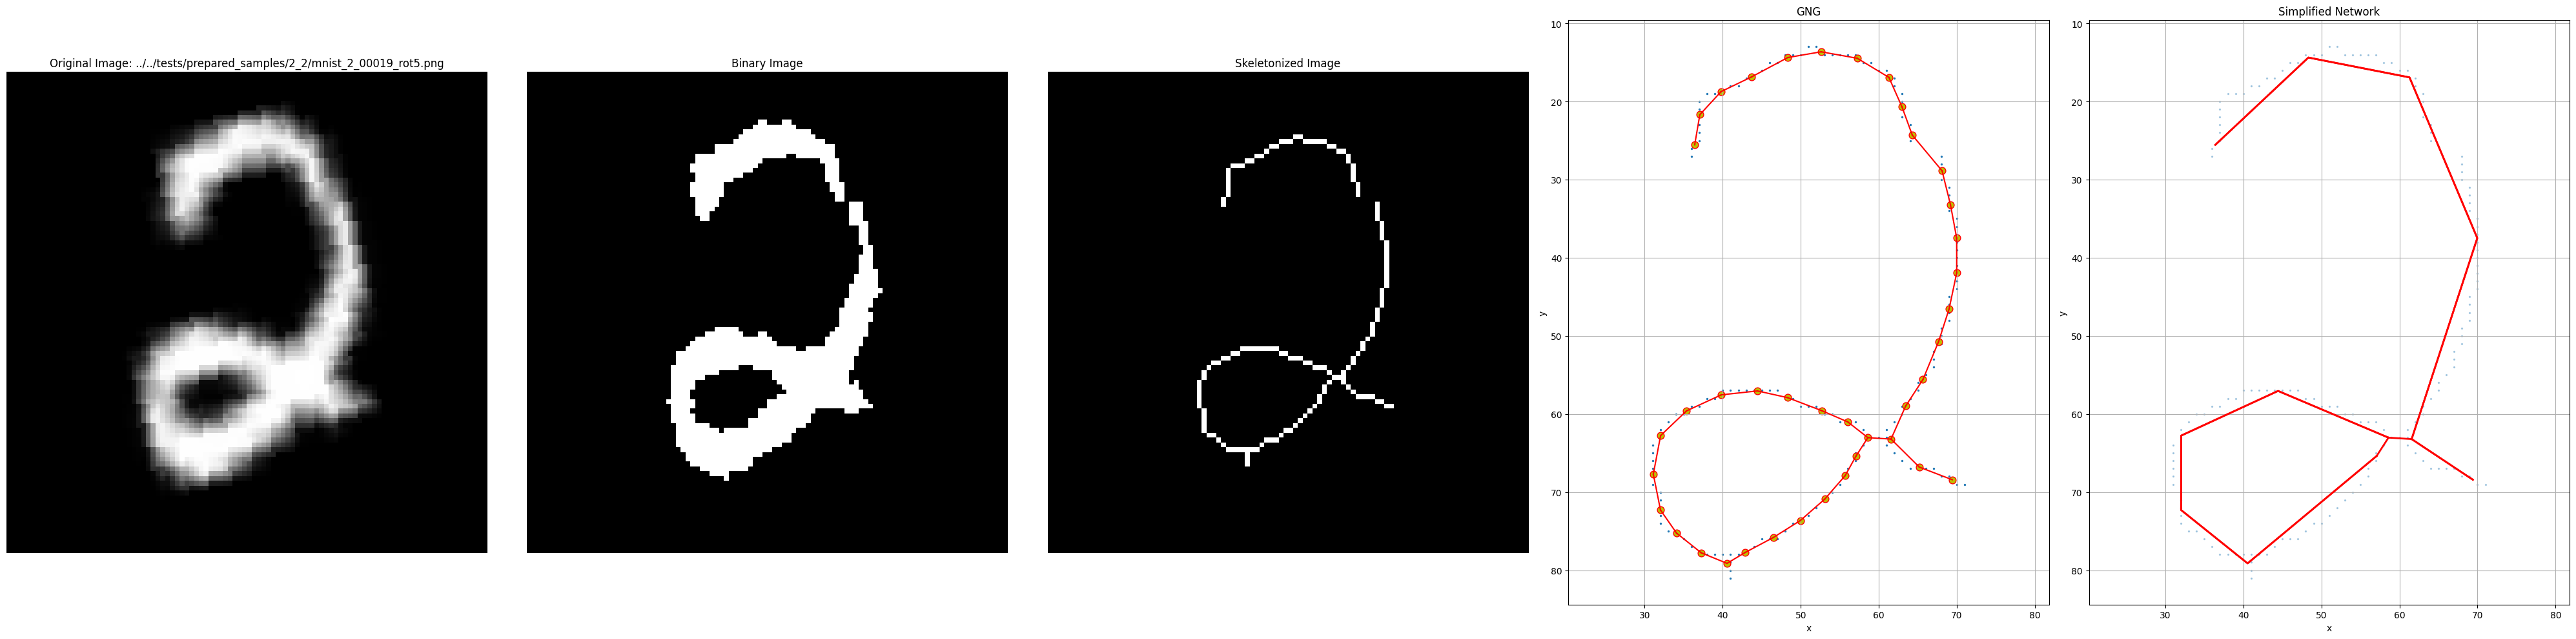

Source: (58.59276628745357, 63.030251194889686), Target: (61.5595961015613, 63.21530738509565)
Source: (58.59276628745357, 63.030251194889686), Target: (44.445612563906074, 57.05171539170049)
Source: (44.445612563906074, 57.05171539170049), Target: (32.038028672306865, 62.770085722163024)
Source: (32.038028672306865, 62.770085722163024), Target: (32.02334718046725, 72.29618088389607)
Source: (32.02334718046725, 72.29618088389607), Target: (40.5446877624202, 79.12428643325389)
Source: (40.5446877624202, 79.12428643325389), Target: (57.081223745787646, 65.37382955936529)
Source: (57.081223745787646, 65.37382955936529), Target: (58.59276628745357, 63.030251194889686)
Source: (57.081223745787646, 65.37382955936529), Target: (40.5446877624202, 79.12428643325389)
Source: (40.5446877624202, 79.12428643325389), Target: (32.02334718046725, 72.29618088389607)
Source: (32.02334718046725, 72.29618088389607), Target: (32.038028672306865, 62.770085722163024)
Source: (32.038028672306865, 62.770085722

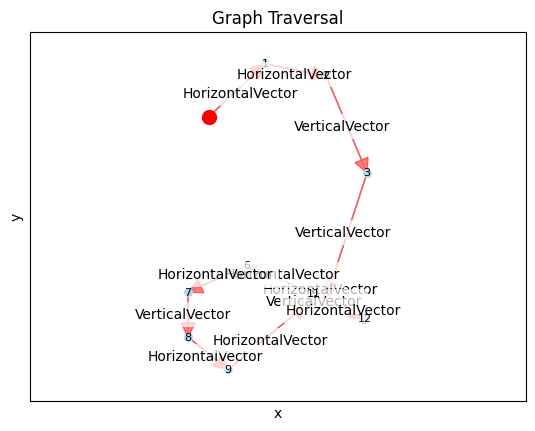

In [93]:
from skimage.filters import threshold_otsu

params = structure()
params.N = 40 # Number of neuronsq
params.maxit = 100 # Maximum number of iterations
params.L = 40 # Learning rate
params.epsilon_b = 0.2 # Basal lr
params.epsilon_n = 0.01 # Neighborhood lr
params.alpha = 0.5 # Learning rate decay
params.delta = 0.995 # Neighborhood radius decay
params.T = 100 # Number of epochs


binary_threshold = 170
epsilon = 4

# Get 10 random images from the folder
folder_path = '../../tests/prepared_samples/2_2'
# folder_path = '../../tests/generated_samples/mnist_1/train'
images = [os.path.join(folder_path, file) for file in sorted(os.listdir(folder_path)) if file.endswith((".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".gif"))]
# random_images = np.random.choice(images, len(images), replace=False)

class_number = 2
image_number = 45
# images = [f'../../tests/generated_samples/mnist_{class_number}/test/mnist_{class_number}_{image_number:05d}.png']

for image_path in images:
    image = imread(image_path, 0)
    # binary_threshold = threshold_otsu(image)
    # print(f"Binary threshold: {binary_threshold}")
    binary = binary_image(image_path)
    skeleton = skeleton_image(image_path)
    image_points = get_image_points(skeleton)
    network = gng_process(image_points)
    simplified_network = simplify_network(network, epsilon=epsilon)
    plot_network_result(image_path, network, params, image_points, image, binary, skeleton, simplified_network)
    
    G = to_networkx(simplified_network)
    
    # analyzer = CurveAnalyzer(G)
    # analyzer.debug_visualize_graph()
    # curves = analyzer.analyze()
    # analyzer.visualize(curves)
    
    cycles = list(nx.simple_cycles(G))
    print(f"Cycles: {len(cycles)}")
    if not nx.is_connected(G):
        print(f"Graph {image_path} is not connected")
        continue
    top_leftmost_point = find_top_leftmost_point(G)
    print(f"Top leftmost point: {G.nodes[top_leftmost_point]}")    
    traversal = GraphTraversal(G).dfs_traversal(start_node=top_leftmost_point)
    
    plot_graph_traversal(plt.gca(), G, traversal)
    plt.show()